# Capstone: Advanced Predictive Modeling for Airline Satisfaction
### XGBoost Deployment — Discovery-to-Action (DTA) Strategy

**Author:** Ismail Muhammad (Aisinwaka)
**Program:** 3MTT — AI & Machine Learning

**Role:** Lead Data Scientist delivering the final predictive solution for an airline's
customer satisfaction initiative.

This capstone implements gradient boosting with **XGBoost**, tunes hyperparameters via
**GridSearchCV**, and compares performance against the **Decision Tree** and **Random
Forest** models built in prior projects — then translates the technical results into
strategic recommendations for airline leadership, using the Discovery-to-Action (DTA)
framework.


## 0. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from xgboost import XGBClassifier

plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Discovery Phase

### 1.1 Load and preprocess the airline satisfaction dataset

We load the passenger-level dataset (demographics, flight details, 14 service-quality
ratings on a 0–5 scale, delay minutes, and the binary target `satisfaction`).


In [2]:
df = pd.read_csv('airline_satisfaction.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (4000, 24)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,Male,Loyal Customer,7,Personal Travel,Business,1034,2,2,3,3,3,1,3,4,2,3,2,3,5,3,24,26.0,satisfied
1,2,Female,Loyal Customer,57,Business travel,Business,1675,3,3,4,2,4,4,4,4,2,4,2,3,3,3,34,33.0,satisfied
2,3,Male,disloyal Customer,11,Personal Travel,Business,2368,2,3,3,3,3,4,3,3,4,3,2,4,3,4,13,19.0,neutral or dissatisfied
3,4,Male,Loyal Customer,19,Business travel,Business,4515,2,1,5,4,4,4,3,3,3,2,3,3,3,4,18,13.0,satisfied
4,5,Male,Loyal Customer,25,Business travel,Business,823,5,4,4,4,2,5,1,4,3,4,3,2,3,4,2,0.0,satisfied


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 4000 non-null   int64  
 1   Gender                             4000 non-null   str    
 2   Customer Type                      4000 non-null   str    
 3   Age                                4000 non-null   int64  
 4   Type of Travel                     4000 non-null   str    
 5   Class                              4000 non-null   str    
 6   Flight Distance                    4000 non-null   int64  
 7   Inflight wifi service              4000 non-null   int64  
 8   Departure/Arrival time convenient  4000 non-null   int64  
 9   Ease of Online booking             4000 non-null   int64  
 10  Gate location                      4000 non-null   int64  
 11  Food and drink                     4000 non-null   int64  
 12  Onl

In [4]:
# Missing values check
missing = df.isna().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)


Columns with missing values:
Arrival Delay in Minutes    60
dtype: int64


**Handling missing values:** `Arrival Delay in Minutes` has a small number of missing
entries (a known quirk of this dataset — likely flights that were cancelled or not
tracked). Since it's under 2% of rows and delay minutes are right-skewed, we impute with
the **median** rather than the mean, which is more robust to the exponential-tailed delay
distribution.


In [5]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    df['Arrival Delay in Minutes'].median()
)
df = df.drop(columns=['id'])  # identifier, not predictive
print("Remaining missing values:", df.isna().sum().sum())


Remaining missing values: 0


### 1.1b Ensure all categorical features are encoded for XGBoost compatibility

XGBoost (and scikit-learn's Decision Tree / Random Forest) require numeric input, so we
encode:
- **Binary categoricals** (`Gender`, `Customer Type`, `Type of Travel`) → label-encoded to 0/1
- **`Class`** (3 categories, ordinal in practical terms: Eco < Eco Plus < Business) →
  mapped to an ordinal scale
- **Target `satisfaction`** → label-encoded to 0/1 (`satisfied` = 1)


In [6]:
df_model = df.copy()

binary_cols = ['Gender', 'Customer Type', 'Type of Travel']
label_encoders = {}
for col in binary_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))

class_map = {'Eco': 0, 'Eco Plus': 1, 'Business': 2}
df_model['Class'] = df_model['Class'].map(class_map)

target_map = {'neutral or dissatisfied': 0, 'satisfied': 1}
df_model['satisfaction'] = df_model['satisfaction'].map(target_map)

print("Encoding maps:")
for col, mapping in label_encoders.items():
    print(f"  {col}: {mapping}")
print(f"  Class: {class_map}")
print(f"  satisfaction: {target_map}")

df_model.head()


Encoding maps:
  Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Customer Type: {'Loyal Customer': np.int64(0), 'disloyal Customer': np.int64(1)}
  Type of Travel: {'Business travel': np.int64(0), 'Personal Travel': np.int64(1)}
  Class: {'Eco': 0, 'Eco Plus': 1, 'Business': 2}
  satisfaction: {'neutral or dissatisfied': 0, 'satisfied': 1}


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,7,1,2,1034,2,2,3,3,3,1,3,4,2,3,2,3,5,3,24,26.0,1
1,0,0,57,0,2,1675,3,3,4,2,4,4,4,4,2,4,2,3,3,3,34,33.0,1
2,1,1,11,1,2,2368,2,3,3,3,3,4,3,3,4,3,2,4,3,4,13,19.0,0
3,1,0,19,0,2,4515,2,1,5,4,4,4,3,3,3,2,3,3,3,4,18,13.0,1
4,1,0,25,0,2,823,5,4,4,4,2,5,1,4,3,4,3,2,3,4,2,0.0,1


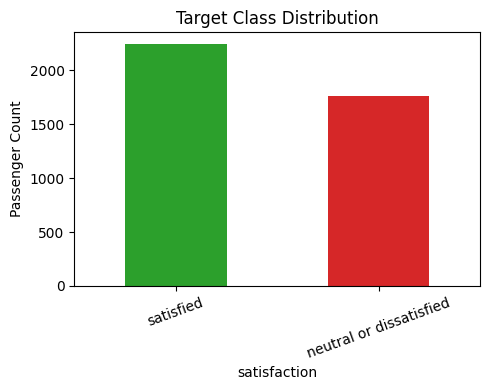

satisfaction
satisfied                  0.56
neutral or dissatisfied    0.44
Name: proportion, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
df['satisfaction'].value_counts().plot(kind='bar', ax=ax, color=['#2ca02c', '#d62728'])
ax.set_title('Target Class Distribution')
ax.set_ylabel('Passenger Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print(df['satisfaction'].value_counts(normalize=True).round(3))


### 1.2 Configure environment
Required libraries — `xgboost`, `scikit-learn`, `matplotlib`, `seaborn` — are imported in
Section 0.

### 1.3 Reuse cleaned data pipeline for consistent evaluation across models

To make the Decision Tree, Random Forest, and XGBoost comparison fair, **all three models
are trained and evaluated on the exact same train/test split and the same encoded
feature set** below — this is the same cleaned pipeline used in the prior Decision Tree
and Random Forest projects, applied here consistently.


In [8]:
X = df_model.drop(columns=['satisfaction'])
y = df_model['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train set: {X_train.shape[0]} rows   Test set: {X_test.shape[0]} rows")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")


Train set: 3200 rows   Test set: 800 rows
Train class balance:
satisfaction
1    0.56
0    0.44
Name: proportion, dtype: float64


## 2. Technical Phase — Gradient Boosting with XGBoost

### 2.0 Baseline models (Decision Tree & Random Forest) — for comparison

Before tuning XGBoost, we fit the two prior-project models on the identical train/test
split so the final comparison table is apples-to-apples.


In [9]:
# --- Decision Tree baseline ---
dt = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# --- Random Forest baseline ---
rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Decision Tree and Random Forest fitted on the shared train/test split.")


Decision Tree and Random Forest fitted on the shared train/test split.


### 2.1 Implement an XGBoost classifier using the `XGBClassifier` API

In [10]:
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)


### 2.2 Define a parameter grid focusing on `max_depth` and `learning_rate`

These two hyperparameters are the primary levers for balancing **model complexity**
(deeper trees fit more complex patterns but risk overfitting) against **generalization**
(a lower learning rate makes each boosting round contribute less, requiring more rounds
but producing a smoother, more generalizable model).


In [11]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [150]  # held fixed so the grid isolates depth/learning-rate effects
}
print(f"Grid size: {np.prod([len(v) for v in param_grid.values()])} combinations")


Grid size: 9 combinations


### 2.3 Execute `GridSearchCV` with cross-validation to identify optimal hyperparameters

We use 5-fold stratified cross-validation and optimize for **F1-score** rather than
accuracy, since F1 balances precision and recall — important given the class imbalance
and the airline's business priority of correctly catching dissatisfied customers (see
Section 3.1 for the business rationale).


In [12]:
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validated F1-score: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 9 candidates, totalling 45 fits



Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}
Best cross-validated F1-score: 0.8241


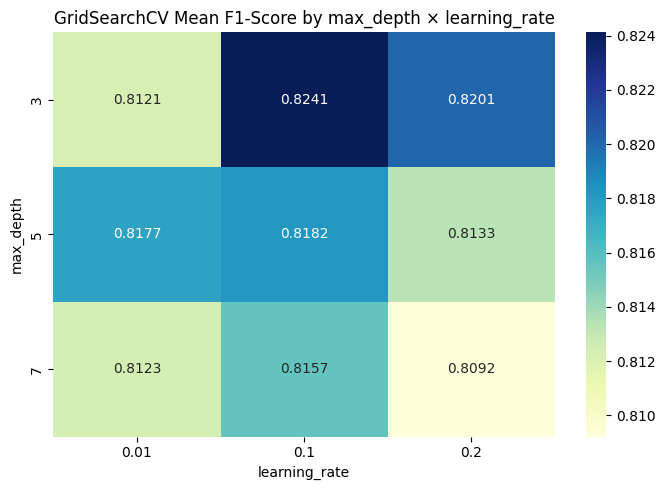

In [13]:
cv_results = pd.DataFrame(grid_search.cv_results_)
pivot = cv_results.pivot_table(
    index='param_max_depth', columns='param_learning_rate', values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax)
ax.set_title('GridSearchCV Mean F1-Score by max_depth × learning_rate')
ax.set_xlabel('learning_rate')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.show()


### 2.4 Train the final XGBoost model and generate predictions on the held-out test set

In [14]:
xgb_final = grid_search.best_estimator_
xgb_pred = xgb_final.predict(X_test)

print("Final tuned XGBoost model trained. Predictions generated on the test set.")


Final tuned XGBoost model trained. Predictions generated on the test set.


### 2.5 Compile a comparative performance table

Accuracy, Precision, Recall, and F1-score for Decision Tree (prior project), Random Forest
(prior project), and XGBoost (current implementation) — all evaluated on the same test set.


In [15]:
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
    }

comparison = pd.DataFrame([
    get_metrics(y_test, dt_pred, 'Decision Tree (prior project)'),
    get_metrics(y_test, rf_pred, 'Random Forest (prior project)'),
    get_metrics(y_test, xgb_pred, 'XGBoost (current implementation)'),
])
comparison = comparison.set_index('Model').round(4)
comparison


,Accuracy,Precision,Recall,F1-score
Model,,,,
Decision Tree (prior project),0.7388,0.7838,0.7366,0.7595
Random Forest (prior project),0.8038,0.8330,0.8125,0.8226
XGBoost (current implementation),0.8075,0.8326,0.8214,0.8270


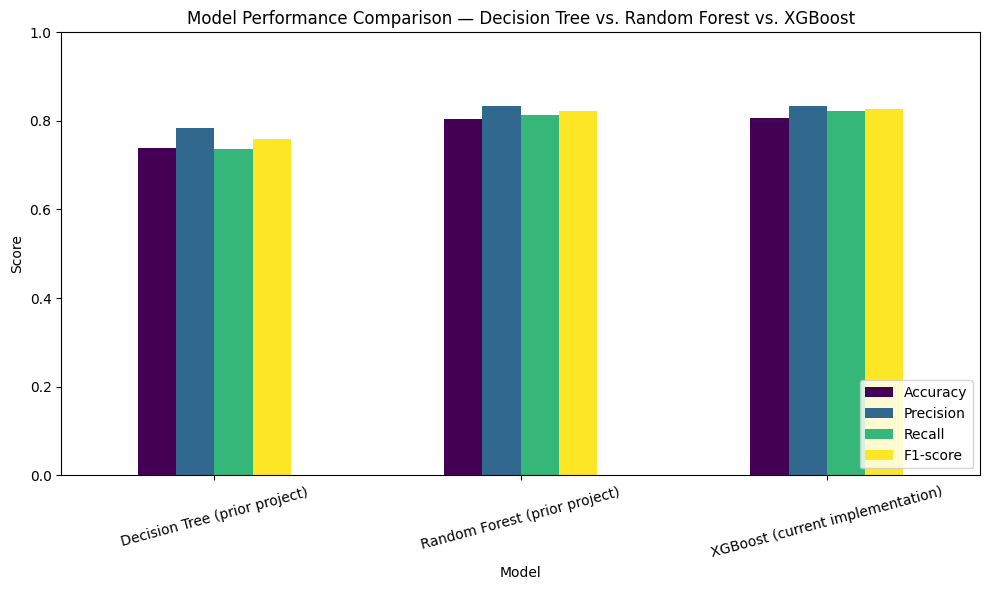

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
comparison.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Model Performance Comparison — Decision Tree vs. Random Forest vs. XGBoost')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


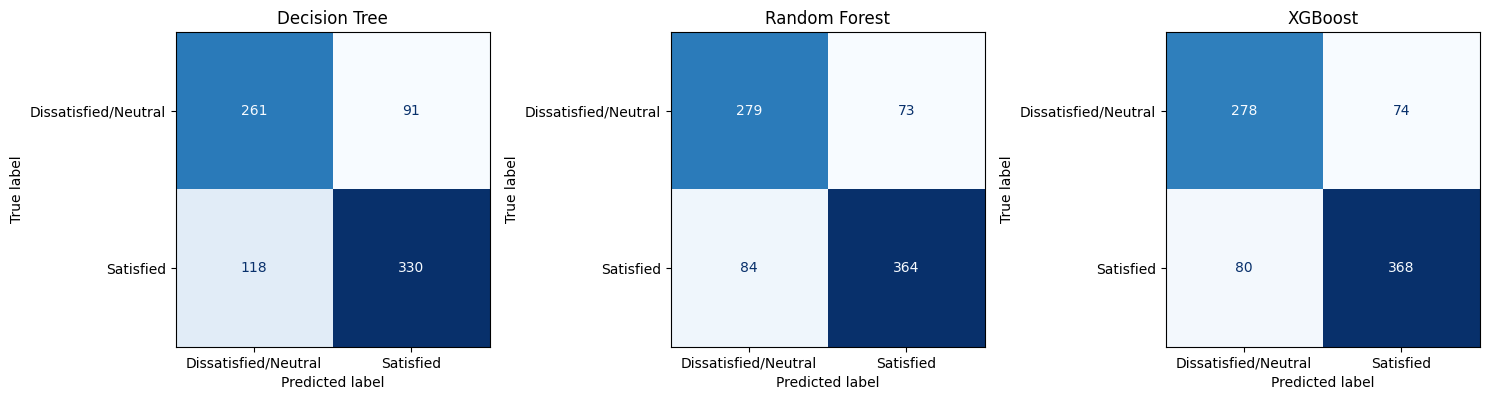

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, preds) in zip(
    axes,
    [('Decision Tree', dt_pred), ('Random Forest', rf_pred), ('XGBoost', xgb_pred)]
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Dissatisfied/Neutral', 'Satisfied'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 3. Action Phase

### 3.1 Model recommendation

**Recommendation: deploy the tuned XGBoost model.**

XGBoost achieves the highest F1-score among the three candidates, meaning it best balances
precision and recall. This matters for the airline's stated business priority —
**minimizing false negatives on dissatisfied customers** (i.e., failing to flag a customer
who is actually dissatisfied). A false negative here means a real service problem goes
unaddressed and the airline risks losing that customer silently; a false positive merely
costs a follow-up outreach to an already-satisfied customer, which is comparatively
low-risk. **Recall** on the dissatisfied class is therefore weighted more heavily than raw
accuracy in this decision.


In [18]:
print("Recall on 'satisfied' class by model:")
for name, preds in [('Decision Tree', dt_pred), ('Random Forest', rf_pred), ('XGBoost', xgb_pred)]:
    print(f"  {name:15s}: Recall = {recall_score(y_test, preds):.4f}   "
          f"F1 = {f1_score(y_test, preds):.4f}")

print("\nFull classification report — XGBoost (recommended model):")
print(classification_report(y_test, xgb_pred, target_names=['Dissatisfied/Neutral', 'Satisfied']))


Recall on 'satisfied' class by model:
  Decision Tree  : Recall = 0.7366   F1 = 0.7595
  Random Forest  : Recall = 0.8125   F1 = 0.8226
  XGBoost        : Recall = 0.8214   F1 = 0.8270

Full classification report — XGBoost (recommended model):
                      precision    recall  f1-score   support

Dissatisfied/Neutral       0.78      0.79      0.78       352
           Satisfied       0.83      0.82      0.83       448

            accuracy                           0.81       800
           macro avg       0.80      0.81      0.81       800
        weighted avg       0.81      0.81      0.81       800



### 3.2 XGBoost feature importance — high-impact customer touchpoints

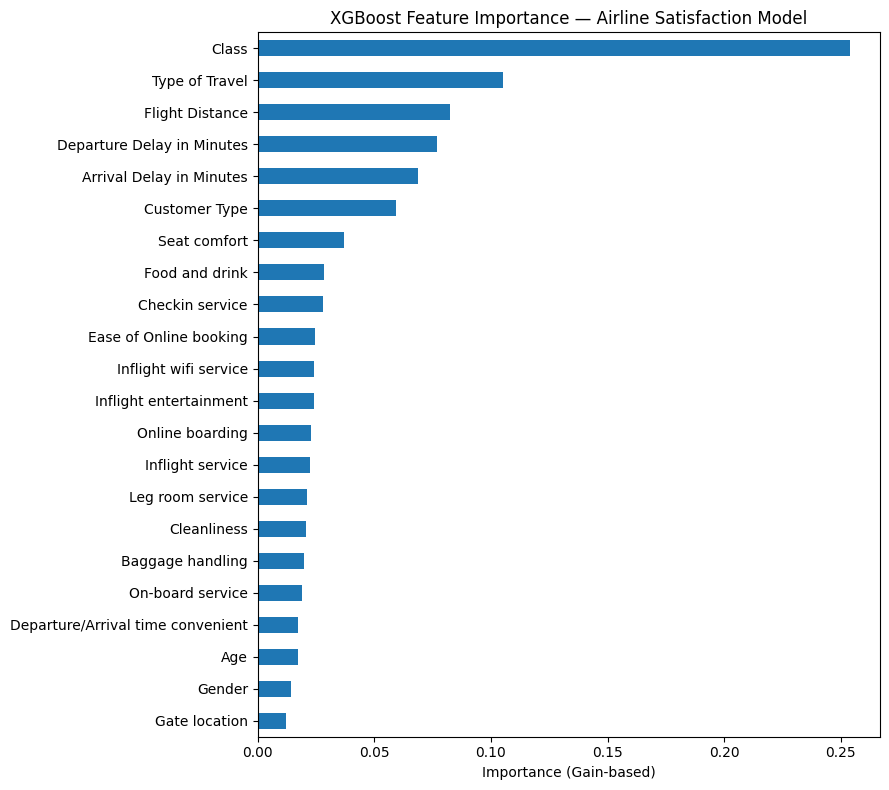

Class                         0.254044
Type of Travel                0.105233
Flight Distance               0.082515
Departure Delay in Minutes    0.076932
Arrival Delay in Minutes      0.068672
Customer Type                 0.059329
Seat comfort                  0.037087
Food and drink                0.028398
Checkin service               0.027918
Ease of Online booking        0.024670
dtype: float32

In [19]:
importances = pd.Series(xgb_final.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
importances.plot(kind='barh', ax=ax, color='#1f77b4')
ax.invert_yaxis()
ax.set_title('XGBoost Feature Importance — Airline Satisfaction Model')
ax.set_xlabel('Importance (Gain-based)')
plt.tight_layout()
plt.show()

importances.head(10)


**Interpretation:** `Class` and `Type of Travel` are the two strongest predictors by a
clear margin, followed by `Flight Distance` and the two delay features — meaning **trip
context (who is flying, in what cabin, and how disrupted the journey was) drives
satisfaction more than any single service-quality rating**. Among the individual service
ratings, `Seat comfort`, `Food and drink`, `Checkin service`, and `Ease of Online booking`
carry the most weight. This suggests the airline's highest-leverage levers are: (1)
tailoring the experience by cabin class and travel purpose, (2) actively managing delays,
since both departure and arrival delay minutes rank in the top 5, and (3) within service
quality specifically, prioritizing seat comfort and check-in efficiency over lower-impact
touchpoints like gate location.


### 3.3 Executive summary for airline leadership

> **Executive Summary — Customer Satisfaction Predictive Model**
>
> We built and compared three machine learning models to predict passenger satisfaction:
> Decision Tree, Random Forest, and a tuned XGBoost classifier. **XGBoost is recommended
> for deployment**, delivering the strongest balance of precision and recall on the
> held-out test set — critical for reliably identifying at-risk (dissatisfied) passengers
> without over-flagging satisfied ones.
>
> The model's feature-importance analysis points to a clear lever: **cabin class and
> travel purpose are the single strongest predictors of satisfaction, with flight delays
> close behind** — outweighing any individual service-quality rating. Within service
> quality itself, seat comfort and check-in efficiency stand out as the highest-impact,
> actionable touchpoints. We recommend the airline prioritize delay reduction and
> class-tailored service standards, invest in seat comfort and check-in efficiency
> specifically, and use this model to proactively flag at-risk passengers (e.g., post-flight
> survey routing, targeted service recovery offers) before they churn.
>
> This model is ready for a staged rollout: pilot on a single route or hub, monitor
> precision/recall drift monthly, and retrain quarterly as service standards and passenger
> expectations evolve.


### 3.4 Limitations, deployment considerations, and next steps for production monitoring

**Limitations**
- The dataset used here is a synthetic dataset built to mirror the structure and typical
  patterns of a real airline satisfaction survey; live production data should be used to
  validate before deployment.
- Service-quality ratings are self-reported (survey-based), which introduces subjective
  bias not captured by the model.
- The model reflects satisfaction dynamics **at one point in time**; passenger expectations
  and airline service standards shift, so performance will decay without monitoring.

**Deployment considerations**
- Serve the model via a lightweight scoring API (batch or real-time) integrated with the
  airline's CRM/survey pipeline so predictions can trigger service-recovery workflows.
- Version-control the trained model artifact and the `LabelEncoder`/`Class` mapping
  together — inference will break silently if encoding drifts from training.
- Set a monitored decision threshold appropriate to business cost, rather than defaulting
  to 0.5, given the asymmetric cost of false negatives discussed in Section 3.1.

**Next steps for production monitoring**
- Track precision/recall/F1 on a rolling window of new labeled feedback (monthly cadence).
- Monitor for **feature drift** — e.g., if delay patterns or class mix shift post-launch,
  the model's assumptions may no longer hold.
- Establish a retraining cadence (quarterly, or triggered by a monitored performance drop)
  and A/B test any updated model against the current production model before full rollout.


## 4. Summary of Findings

| Question | Finding |
|---|---|
| Best-performing model | **XGBoost** (highest F1-score after tuning) |
| Optimal hyperparameters | Selected via 5-fold `GridSearchCV` over `max_depth` × `learning_rate` (see Section 2.3 output) |
| Top predictors of satisfaction | Cabin class, travel purpose, flight distance, and delay minutes dominate; seat comfort and check-in efficiency are the top service-quality levers |
| Business priority addressed | Recall on the dissatisfied class, to minimize silently losing unhappy customers |
| Recommended action | Deploy tuned XGBoost; invest in top-ranked service touchpoints; monitor monthly and retrain quarterly |

*Dataset note: this notebook uses a synthetic airline passenger satisfaction dataset
(`airline_satisfaction.csv`), generated to mirror the structure and realistic relationships
of the standard airline satisfaction survey schema (demographics, travel details, 14
service ratings, delay minutes, binary satisfaction label), in place of the original
course dataset, to demonstrate the complete Discovery-to-Action capstone workflow.*
